# 04 — Subplots & Layouts
**Goal:** Combine multiple charts into one figure — the key skill for building dashboards and reports.

Topics:
- `plt.subplots()` — grid of equal-sized plots
- `gridspec` — unequal sizes, custom layouts
- `tight_layout` vs `constrained_layout`
- Inset axes — a small chart inside another

In [7]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])

# Pre-compute data we'll reuse
daily = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()

channel_cvr = df.groupby('channel').apply(
    lambda g: g['activacion_tarjeta'].sum() / g['visita_landing'].sum() * 100
).sort_values(ascending=False)

print('Data ready')

Data ready


## 1. `plt.subplots(rows, cols)` — equal grid

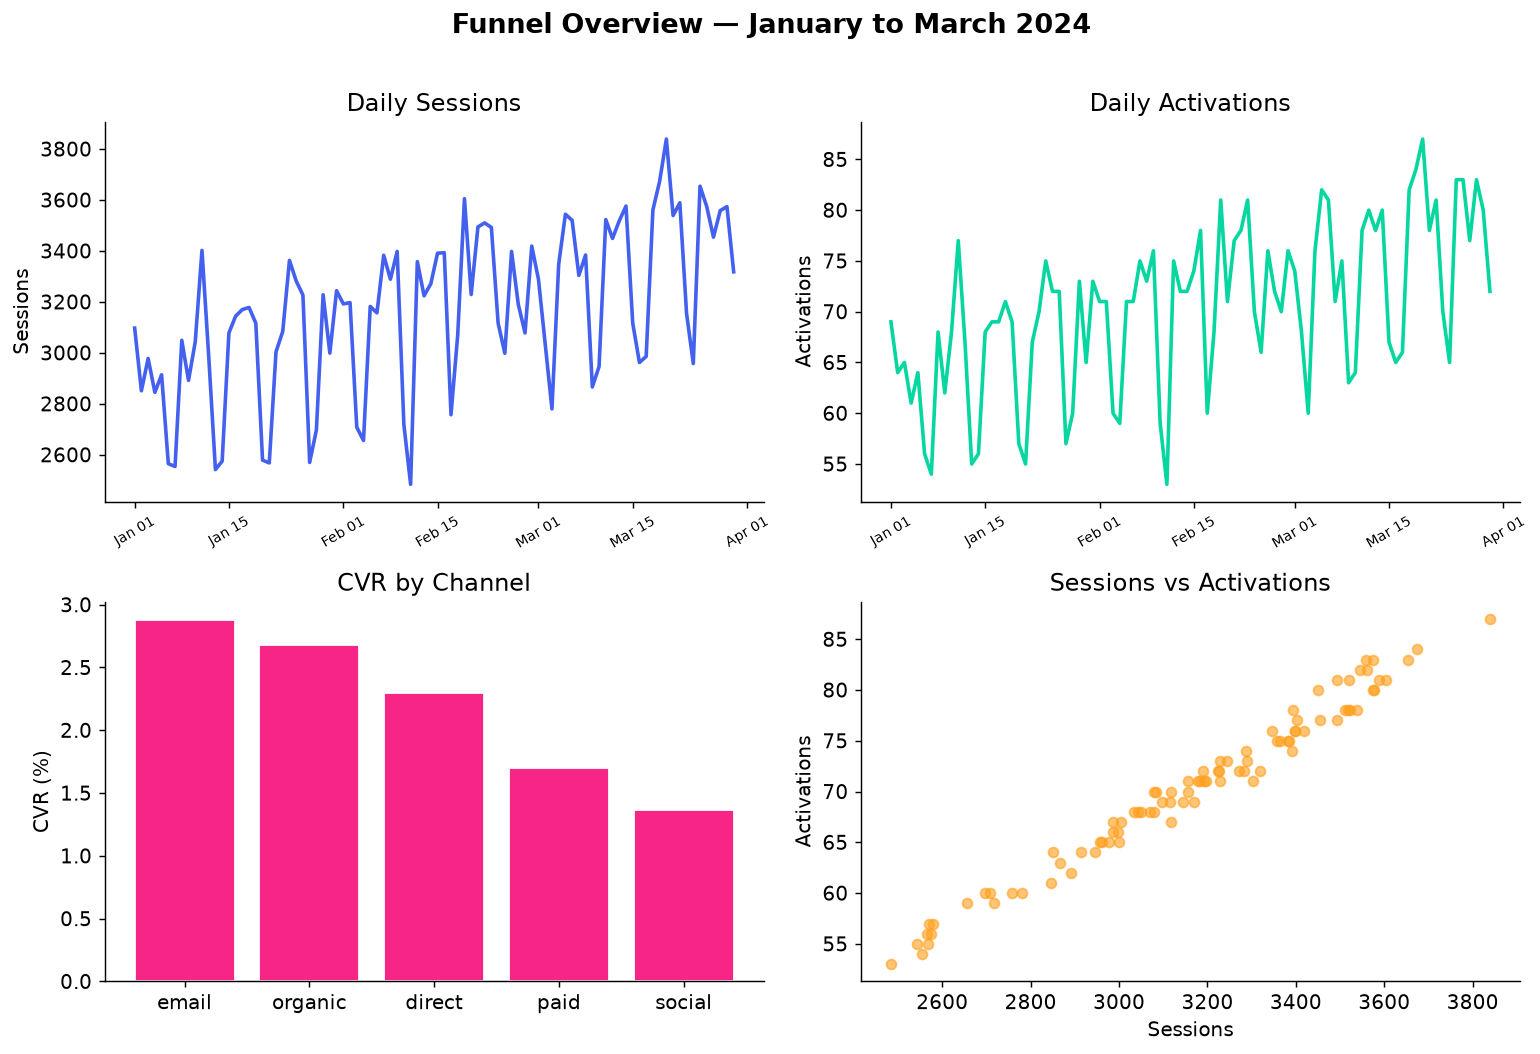

In [8]:
import matplotlib.dates as mdates

# 2 rows, 2 columns = 4 plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=130)

ax_tl = axes[0, 0]
ax_tr = axes[0, 1]
ax_bl = axes[1, 0]
ax_br = axes[1, 1]

# Top-left: sessions trend
ax_tl.plot(daily['date'], daily['sessions'], color='#4361ee', linewidth=2)
ax_tl.set_title('Daily Sessions')
ax_tl.set_ylabel('Sessions')
# Format dates as "Jan 15" to avoid long overlapping strings
ax_tl.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_tl.tick_params(axis='x', rotation=30, labelsize=8)

# Top-right: activations trend
ax_tr.plot(daily['date'], daily['activations'], color='#06d6a0', linewidth=2)
ax_tr.set_title('Daily Activations')
ax_tr.set_ylabel('Activations')
ax_tr.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_tr.tick_params(axis='x', rotation=30, labelsize=8)

# Bottom-left: CVR by channel
ax_bl.bar(channel_cvr.index, channel_cvr.values, color='#f72585', edgecolor='white')
ax_bl.set_title('CVR by Channel')
ax_bl.set_ylabel('CVR (%)')

# Bottom-right: scatter sessions vs activations
ax_br.scatter(daily['sessions'], daily['activations'],
              color='#ff9f1c', alpha=0.6, s=30)
ax_br.set_title('Sessions vs Activations')
ax_br.set_xlabel('Sessions')
ax_br.set_ylabel('Activations')

fig.suptitle('Funnel Overview — January to March 2024',
             fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

## 2. Flattening axes — useful when looping

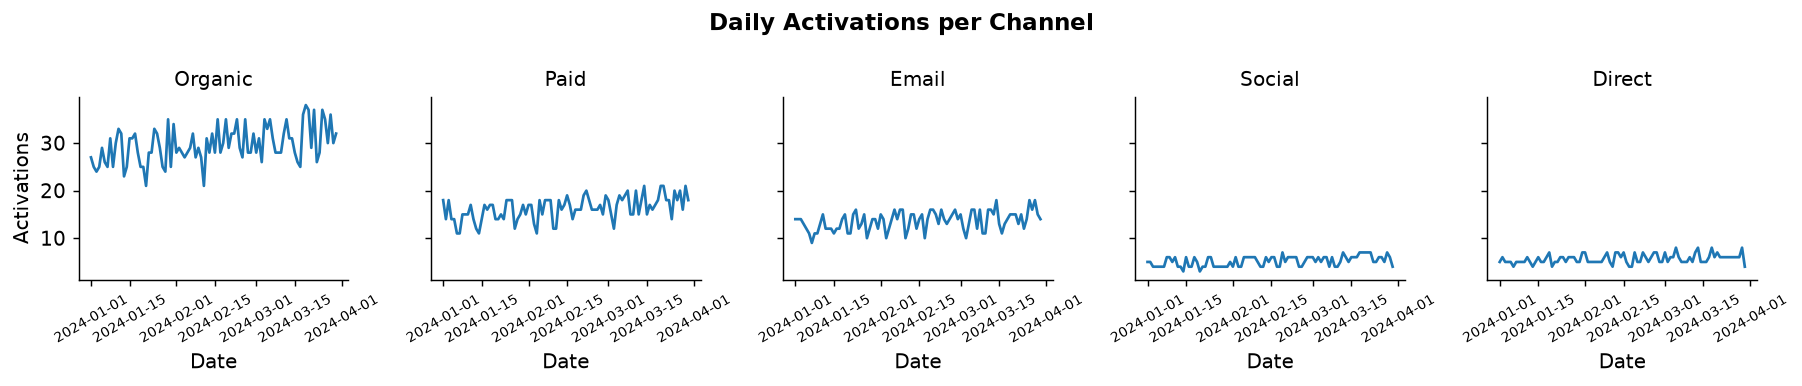

In [9]:
channels = df['channel'].unique()

# 1 row per channel — easier to loop with flat axes array
fig, axes = plt.subplots(1, len(channels), figsize=(14, 3), dpi=130,
                          sharey=True)   # same y axis scale for fair comparison

# axes.flatten() converts 2D array to 1D so we can zip it with channels
for ax, ch in zip(axes, channels):
    ch_daily = df[df['channel'] == ch].groupby('date')['activacion_tarjeta'].sum()
    ax.plot(ch_daily.index, ch_daily.values, linewidth=1.5)
    ax.set_title(ch.capitalize(), fontsize=11)
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=30, labelsize=8)

axes[0].set_ylabel('Activations')
fig.suptitle('Daily Activations per Channel', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. `GridSpec` — custom layout with different-sized panels
Use when you want one wide chart on top and smaller ones below, or any non-equal layout.

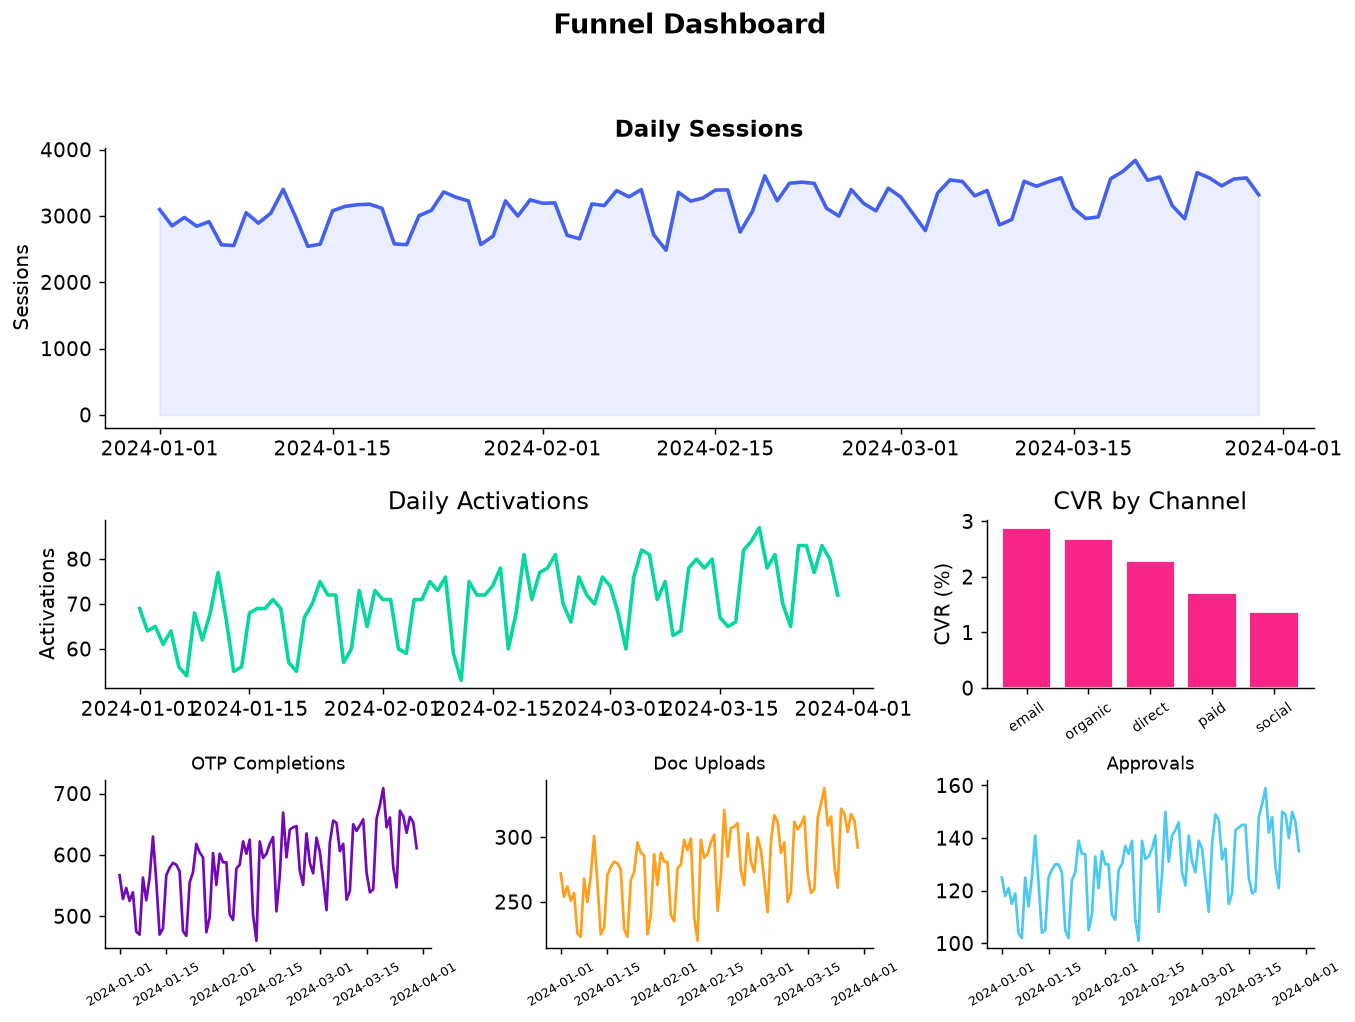

In [10]:
fig = plt.figure(figsize=(12, 8), dpi=130)

# Define a 3-row, 3-column grid
# height_ratios controls relative height of each row
gs = gridspec.GridSpec(3, 3, height_ratios=[2, 1.2, 1.2], hspace=0.45, wspace=0.35)

# Top panel — spans all 3 columns (wide)
ax_top = fig.add_subplot(gs[0, :])   # row 0, all columns
ax_top.plot(daily['date'], daily['sessions'], color='#4361ee', linewidth=2, label='Sessions')
ax_top.fill_between(daily['date'], daily['sessions'], alpha=0.1, color='#4361ee')
ax_top.set_title('Daily Sessions', fontsize=13, fontweight='bold')
ax_top.set_ylabel('Sessions')

# Middle-left — spans 2 columns
ax_mid_l = fig.add_subplot(gs[1, :2])  # row 1, columns 0 and 1
ax_mid_l.plot(daily['date'], daily['activations'], color='#06d6a0', linewidth=2)
ax_mid_l.set_title('Daily Activations')
ax_mid_l.set_ylabel('Activations')

# Middle-right — 1 column
ax_mid_r = fig.add_subplot(gs[1, 2])   # row 1, column 2
ax_mid_r.bar(channel_cvr.index, channel_cvr.values, color='#f72585', edgecolor='white')
ax_mid_r.set_title('CVR by Channel')
ax_mid_r.set_ylabel('CVR (%)')
ax_mid_r.tick_params(axis='x', rotation=35, labelsize=8)

# Bottom — 3 separate panels, one per metric
metrics = [
    ('otp', 'OTP Completions', '#7209b7'),
    ('carga_documentos', 'Doc Uploads', '#ff9f1c'),
    ('aprobacion', 'Approvals', '#4cc9f0'),
]
for col, (metric, title, color) in enumerate(metrics):
    ax = fig.add_subplot(gs[2, col])
    daily_m = df.groupby('date')[metric].sum()
    ax.plot(daily_m.index, daily_m.values, color=color, linewidth=1.5)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

fig.suptitle('Funnel Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('data/04_gridspec_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. `tight_layout` vs `constrained_layout`
Both prevent overlapping labels — `constrained_layout` is the newer, smarter version.

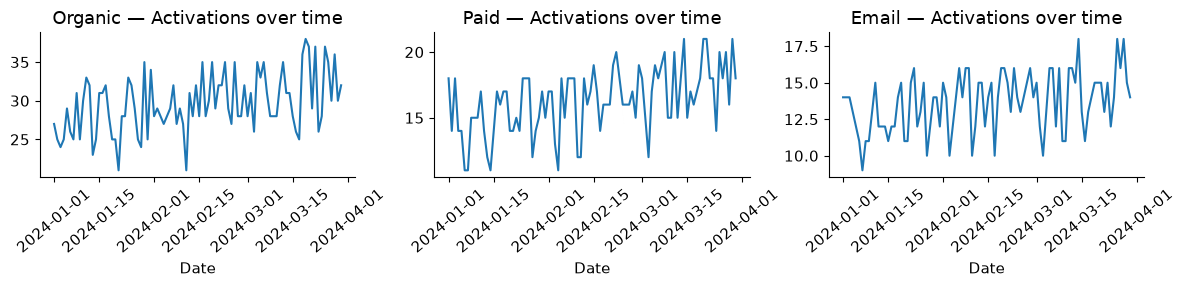

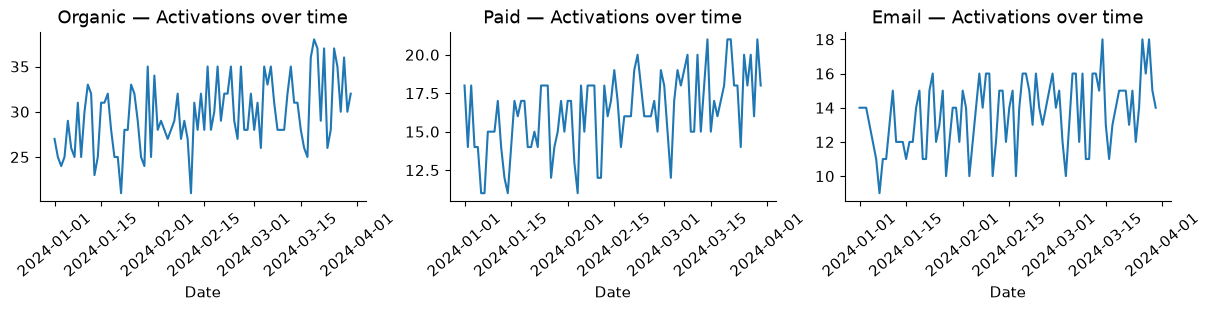

In [11]:
# tight_layout — manual, works most of the time
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, ch in zip(axes, ['organic', 'paid', 'email']):
    d = df[df['channel'] == ch].groupby('date')['activacion_tarjeta'].sum()
    ax.plot(d.index, d.values)
    ax.set_title(f'{ch.capitalize()} — Activations over time')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()   # adjusts spacing to avoid overlap
plt.show()

# constrained_layout — automatic, handles colorbars and legends better
fig, axes = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
for ax, ch in zip(axes, ['organic', 'paid', 'email']):
    d = df[df['channel'] == ch].groupby('date')['activacion_tarjeta'].sum()
    ax.plot(d.index, d.values)
    ax.set_title(f'{ch.capitalize()} — Activations over time')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=40)
plt.show()

## 5. Inset axes — a mini chart inside another

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_8972/4281074320.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


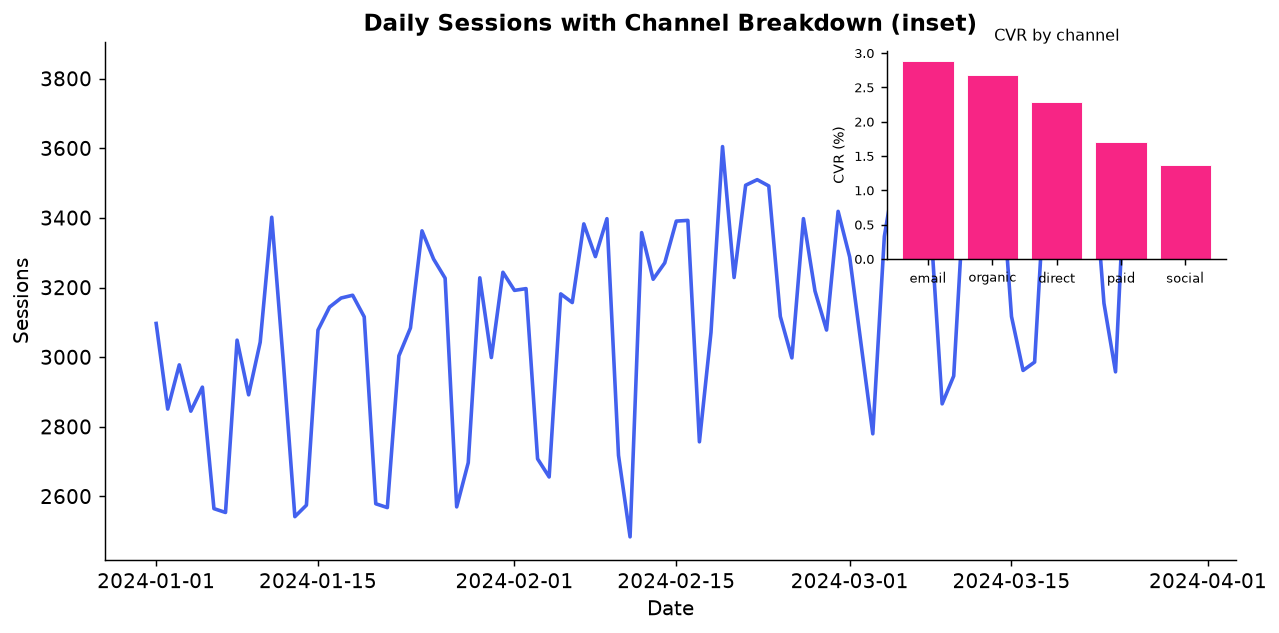

In [12]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(10, 5), dpi=130)

# Main chart: full trend
ax.plot(daily['date'], daily['sessions'], color='#4361ee', linewidth=2)
ax.set_title('Daily Sessions with Channel Breakdown (inset)', fontsize=13, fontweight='bold')
ax.set_ylabel('Sessions')
ax.set_xlabel('Date')

# Inset: CVR by channel — placed in the upper right corner
# width and height are percentages of the parent axes
ax_inset = inset_axes(ax, width='30%', height='40%', loc='upper right')
ax_inset.bar(channel_cvr.index, channel_cvr.values,
             color='#f72585', edgecolor='white', linewidth=0.5)
ax_inset.set_title('CVR by channel', fontsize=9)
ax_inset.tick_params(labelsize=7)
ax_inset.set_ylabel('CVR (%)', fontsize=8)
ax_inset.spines['top'].set_visible(False)
ax_inset.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Summary
| Tool | Use when |
|---|---|
| `plt.subplots(r, c)` | Equal-sized grid of charts |
| `axes.flatten()` | Looping over axes in a grid |
| `sharey=True` | Same y-scale for fair comparison |
| `GridSpec` | Unequal panel sizes, complex layouts |
| `tight_layout()` | Prevent label overlap (simple cases) |
| `constrained_layout=True` | Prevent overlap (complex layouts, legends) |
| `inset_axes` | Small context chart inside a main chart |

**Next:** `05_annotations.ipynb` — adding text, arrows, highlights and LaTeX to charts.